# Financial Analysis of Selected Technology Firms

This project analyzes the financial performance of major technology companies using quarterly data from WRDS.

The analysis focuses on four key dimensions:
- Growth (Revenue)
- Profitability (Net Income)
- Efficiency (ROA)
- Earnings Quality (Profit Margin)

The firms included in this study are Apple, Intel, Microsoft, NVIDIA, and AMD.

## Data Source

The dataset is obtained from WRDS (Compustat Quarterly), including:

- Apple (AAPL)
- Intel (INTC)
- Microsoft (MSFT)
- NVIDIA (NVDA)
- AMD (AMD)

The sample period starts from 2015.

In [3]:
import wrds
import pandas as pd

# 建立连接
db = wrds.Connection()

# 执行 SQL
data = db.raw_sql("""
SELECT gvkey, tic, datadate, revtq, niq, atq
FROM comp.fundq
WHERE tic IN ('AAPL','INTC','MSFT','NVDA','AMD')
AND datadate >= '2015-01-01'
AND datafmt = 'STD'
AND indfmt = 'INDL'
AND consol = 'C'
""")

# 保存数据
data.to_csv("multi_company_data.csv", index=False)

# ❗非常关键：关闭连接
db.close()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
# Convert date
data['datadate'] = pd.to_datetime(data['datadate'])

# Calculate metrics
data['roa'] = data['niq'] / data['atq']
data['profit_margin'] = data['niq'] / data['revtq']

## Data Processing

- Converted date format
- Calculated:
  - Return on Assets (ROA)
  - Profit Margin

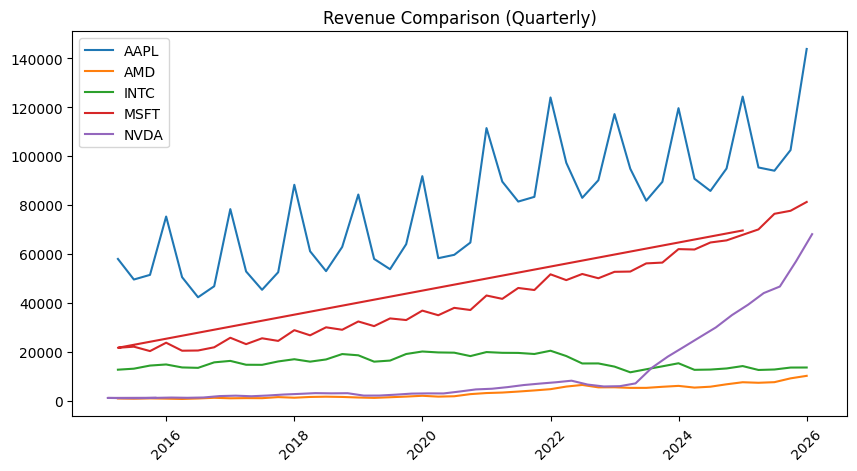

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for company in data['tic'].unique():
    subset = data[data['tic'] == company]
    plt.plot(subset['datadate'], subset['revtq'], label=company)

plt.legend()
plt.title("Quarterly Revenue Comparison Across Firms")
plt.xticks(rotation=45)
plt.show()

## Revenue Analysis

Revenue reflects firm growth and market expansion.

Apple and Microsoft show strong and consistent revenue growth.

NVIDIA and AMD demonstrate high growth but with more volatility.

Intel shows relatively slower growth compared to peers.

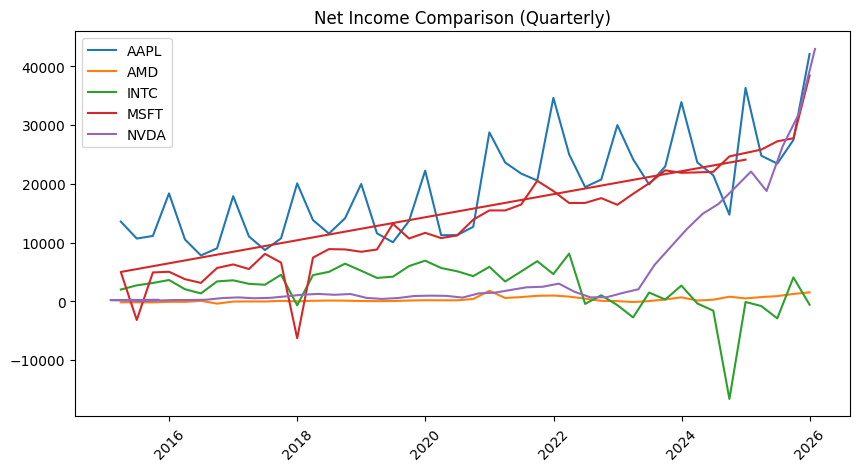

In [6]:
plt.figure(figsize=(10,5))

for company in data['tic'].unique():
    subset = data[data['tic'] == company]
    plt.plot(subset['datadate'], subset['niq'], label=company)

plt.legend()
plt.title("Net Income Comparison (Quarterly)")
plt.xticks(rotation=45)
plt.show()

## Profitability Analysis

Net income measures the firm’s ability to generate profit.

Apple maintains high and stable profitability.

Microsoft also shows strong performance.

Intel and AMD show more fluctuations, indicating less stable profitability.

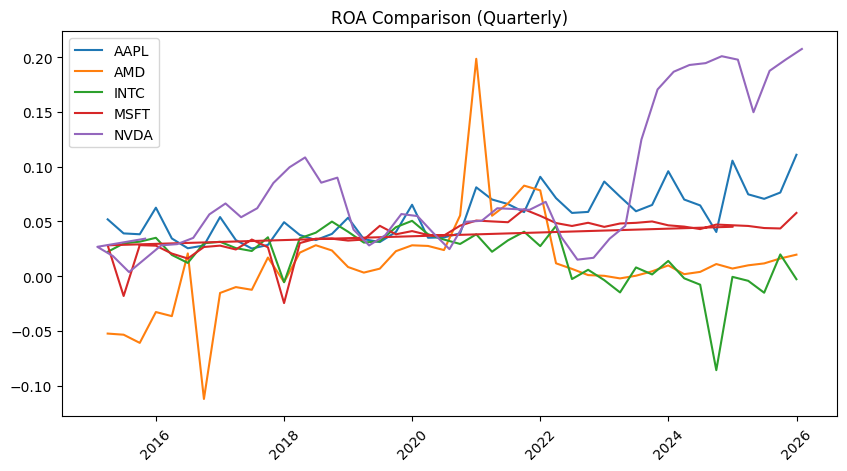

In [7]:
plt.figure(figsize=(10,5))

for company in data['tic'].unique():
    subset = data[data['tic'] == company]
    plt.plot(subset['datadate'], subset['roa'], label=company)

plt.legend()
plt.title("ROA Comparison (Quarterly)")
plt.xticks(rotation=45)
plt.show()

## Efficiency Analysis (ROA)

ROA measures how efficiently a firm uses its assets.

Apple and Microsoft show consistently strong efficiency.

Intel shows declining efficiency over time.

NVIDIA shows strong performance but with higher volatility.

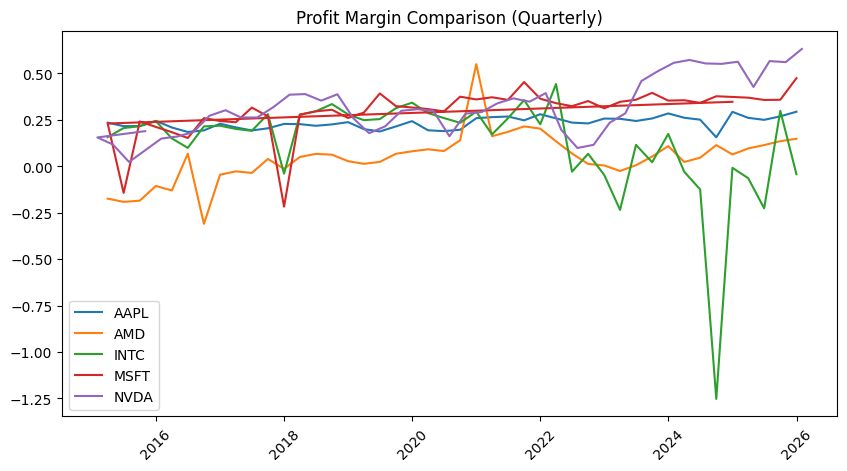

In [9]:
plt.figure(figsize=(10,5))

for company in data['tic'].unique():
    subset = data[data['tic'] == company]
    plt.plot(subset['datadate'], subset['profit_margin'], label=company)
data['profit_margin'] = (data['niq'] / data['revtq']).clip(-0.5, 0.5)
plt.legend()
plt.title("Profit Margin Comparison (Quarterly)")
plt.xticks(rotation=45)
plt.show()

## Earnings Quality (Profit Margin)

Profit margin reflects how much profit is generated from revenue.

Apple maintains high and stable margins, indicating strong pricing power.

Microsoft also shows stable and strong margins.

Intel shows declining and volatile margins, suggesting operational challenges.

AMD and NVIDIA show growth potential but with higher variability.

## Conclusion

This analysis highlights significant differences in financial performance across the selected firms.

Apple consistently demonstrates strong performance across growth, profitability, efficiency, and earnings quality.

Microsoft and NVIDIA also show competitive strength, while AMD presents growth potential with higher volatility.

In contrast, Intel exhibits weaker growth and declining efficiency, indicating structural challenges.

Based on these findings, a long-short strategy is supported:
- Long Apple
- Short Intel

Overall, this framework provides a scalable approach to evaluating firm performance using financial data.